### Чтение датасета

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('D:/Загрузки/skempi_v2.csv', sep=';')

### Приводим столбцы констант связывания к числовому формату и рассчитываем ddG

In [3]:
cols = ['Affinity_wt (M)', 'Affinity_mut (M)']
df[cols] = df[cols].apply(
    lambda x: (
        x.astype(str)  # Приводим всё к строковому типу для гарантии
        .str.replace(',', '.')  # Заменяем запятые на точки
        .str.replace('[<≥>~]', '', regex=True)  # Удаляем символы <, >, ≥
    )
)

In [4]:
def is_number(x):
    try:
        return not pd.isnull(float(x))
    except (ValueError, TypeError):
        return False

In [ ]:
mask = df[cols].applymap(is_number).all(axis=1)
df_numeric = df[mask]
df_numeric['Affinity_mut (M)'] = pd.to_numeric(df_numeric['Affinity_mut (M)'], errors='coerce')
df_numeric['Affinity_wt (M)'] = pd.to_numeric(df_numeric['Affinity_wt (M)'], errors='coerce')
df_numeric['dG_wt'] = np.log(df_numeric['Affinity_wt (M)'])*(8.314/4184) * (273.15 + 25.0) # Рассчет ddG
df_numeric['dG_mut'] = np.log(df_numeric['Affinity_mut (M)'])*(8.314/4184) * (273.15 + 25.0)

In [ ]:
df_numeric['ddG'] = df_numeric['dG_mut'] - df_numeric['dG_wt']
df_numeric['ddG'] = df_numeric['ddG'].apply(lambda x: 1 if x >= 0 else 0)

### Выбираем только одиночные мутации, в дальнейшем будем работать только с ними

In [ ]:
df_numeric['Mutation(s)_cleaned'] = df_numeric['Mutation(s)_cleaned'].apply(lambda x: x.split(','))

In [8]:
df_single = df_numeric[df_numeric['Mutation(s)_cleaned'].str.len() == 1]

In [9]:
df_single = df_single.reset_index(drop=True)

### Построение графов
Будем создавать графы белков, где вершины - аминокислоты. Между вершинами есть ребра, если расстояние между аминокислотами меньше 6А. В качестве node features используем one-hot encoding аминокислоты, физико-химические свойства, структурные свойства(углы фи и пси). Из-за нехватки времени в данном подходе использовались только pdb файлы для wild-type белков. Для построения графа мутантных белков немного видоизменяется исходный граф wild-type белка, что конечно влияет на точность. Я хотел сделать мутацию в Pymol и релаксировать структуру с мутацией с помощью FoldX, однако для обработки одного белка требовалось слишком много времени, поэтому для тестового задания пришлось отказаться от этого подхода. По этой же причине не были добавлены некоторые интересные свойства по типо количества водородных связей, доступности поверхности и др.

In [10]:
ressymbl = {'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU':'E', 'PHE': 'F', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN':'Q', 'ARG':'R', 'SER': 'S','THR': 'T', 'VAL': 'V', 'TRP':'W', 'TYR': 'Y'}

In [11]:
import Bio.PDB as PDB
import pathlib
import os
import urllib.request
import numpy as np
import biographs as bg
from Bio import SeqIO
import torch
import networkx as nx
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import add_self_loops, degree
import scipy
from tqdm import tqdm
from torch_geometric.data import Dataset, download_url, Data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import freesasa

In [28]:
pro_res_table = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

# Dictionary for getting Residue symbols
ressymbl = {'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU':'E', 'PHE': 'F', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L', 'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN':'Q', 'ARG':'R', 'SER': 'S','THR': 'T', 'VAL': 'V', 'TRP':'W', 'TYR': 'Y'}

aa_properties = {  # полярность(1)/неполярность(0); вандервальсов радиус; pI; Гидрофобность; Заряд; pKa(R), Normalized frequency of turn (Crawford et al., 1973), Normalized frequency of alpha-helix (Burgess et al., 1974)
    'G': [0, 48, 6.06, -0.4, 0, 0, 1.38, 0.12],     # Глицин 
    'A': [0, 67, 6.01, 1.8, 0, 0, 0.6, 0.486],      # Аланин
    'V': [0, 105, 6.00, 4.2, 0, 0, 0.48, 0.379],     # Валин
    'I': [0, 124, 6.05, 4.5, 0, 0, 0.67, 0.37],     # Изолейцин
    'L': [0, 124, 6.01, 3.8, 0, 0, 0.7, 0.42],     # Лейцин
    'P': [0, 90, 6.30, -1.6, 0, 0, 1.47, 0.208],     # Пролин
    'S': [1, 73, 5.68, -0.8, 0, 0, 1.26, 0.2],     # Серин
    'T': [1, 93, 5.60, -0.7, 0, 0, 1.05, 0.272],     # Треонин
    'C': [1, 86, 5.05, 2.5, 0, 8.33, 1.29, 0.2],   # Цистеин
    'M': [0, 124, 5.74, 1.9, 0, 0, 0.67, 0.417],     # Метионин
    'D': [1, 91, 2.85, -3.5, -1, 3.65, 1.24, 0.288], # Аспарагиновая кислота
    'N': [1, 96, 5.41, -3.5, 0, 0, 1.42, 0.193],     # Аспарагин
    'E': [1, 109, 3.15, -3.5, -1, 4.25, 0.64, 0.538],# Глутаминовая кислота
    'Q': [1, 114, 5.65, -3.5, 0, 0, 0.92, 0.418],    # Глутамин
    'K': [1, 135, 9.60, -3.9, 1, 10.28, 1.1, 0.402],# Лизин
    'R': [1, 148, 10.76, -4.5, 1, 12.48, 0.79, 0.262],# Аргинин
    'H': [1, 118, 7.60, -3.2, 1, 6.0, 0.95, 0.4], # Гистидин
    'F': [0, 135, 5.49, 2.8, 0, 0, 1.05, 0.288],     # Фенилаланин
    'Y': [1, 141, 5.64, -1.3, 0, 10.1, 1.35, 0.161], # Тирозин
    'W': [0, 163, 5.89, -0.9, 0, 0, 1.23, 0.462]     # Триптофан
}


In [32]:
def create_graph():
    files_with_errors = []
    count1 = 0
    count2 = 0
    count3 = 0
    count4 = 0
    
    def get_local_graph(node_feats, ca_coords, edge_index, mut_index, radius=6.0):
        
        # 1. Посчитать расстояния до мутанта
        dists = np.linalg.norm(ca_coords - ca_coords[mut_index], axis=1)
        local_mask = dists <= radius
    
        # 2. Получить индексы локальных узлов
        local_indices = np.where(local_mask)[0]
        idx_map = {old: new for new, old in enumerate(local_indices)}
    
        # 3. Оставить только локальные признаки
        local_feats = node_feats[local_indices]
        local_coords = ca_coords[local_indices]
    
        # 4. Оставить только рёбра между локальными узлами
        local_edges = []
        for src, dst in edge_index.t().numpy():
            if src in idx_map and dst in idx_map:
                local_edges.append([idx_map[src], idx_map[dst]])
        if local_edges:
            local_edge_index = torch.tensor(local_edges, dtype=torch.long).t()
        else:
            local_edge_index = torch.empty((2,0), dtype=torch.long)
    
        return local_feats, local_edge_index, local_indices
    
    def create_mutants(pdb, seq_dict, node_feats, edge_index, ca_coords):
        #Проходимся по датасету и отбираем белки/мутации
        for idx, row in df_single[df_single['#Pdb'] == pdb].iterrows():
            prev, chain, num, mut = row['Mutation(s)_cleaned'][0][0], row['Mutation(s)_cleaned'][0][1], row['Mutation(s)_cleaned'][0][2:-1], row['Mutation(s)_cleaned'][0][-1]
            if (num, chain) in seq_dict.keys():
                if seq_dict[(num, chain)][0] == prev:
                    try:
                        # Делаем замену тех features, которые характерны для мутатной аминокислоты
                        node_feats_mut = node_feats.clone().detach()
                        number = seq_dict[(num, chain)][1]
                        col_new = pro_res_table.index(mut)
                        col_old = pro_res_table.index(prev)
                        node_feats_mut[number,col_new] = 1
                        node_feats_mut[number,col_old] = 0
                        node_feats_mut[number,24:32] = torch.tensor(aa_properties[mut])
                        
                        # Получаем локальный граф для wild-type и мутантного белка в окрестности 6А от мутантной аминокислоты
                        local_wt_features, local_edge_index, local_indices = get_local_graph(node_feats, ca_coords, edge_index, number)
                        print('Получены локальные характеристики')
                        local_mut_features = node_feats_mut[local_indices] 
                        
                        data_wt = Data(x=local_wt_features, edge_index=local_edge_index)
                        torch.save(data_wt, output_dir + '/' + f"{pdb}_{prev + chain + num + mut}" + '_wt.pt')
                        print(f'Данные сохранены успешно {pdb}_{prev + chain + num + mut}_wt.pt')
    
                        data_mut = Data(x=local_mut_features, edge_index=local_edge_index)
                        torch.save(data_mut, output_dir + '/' + f"{pdb}_{prev + chain + num + mut}" + '_mut.pt')
                        print(f'Данные сохранены успешно {pdb}_{prev + chain + num + mut}_mut.pt')
                    except Exception as e:
                        print(f'Error: {e}')
                    
                else:
                    print('не совпадают аминокислоты по номерам')
            else:
                print('Не совпадают ключи seq_dict')
                
                    
            
    def _get_adjacency(ca_coords, threshold = 6):
        #Получаем бинарную маску для матрицы контактов
        ca_distance = np.linalg.norm(ca_coords[:, None, :] - ca_coords[None, :, :], axis=-1)
        adjacency_matrix = ca_distance < threshold
        return adjacency_matrix
    
    def _get_edgeindex(adjacency_matrix):
        #Получаем список смежности, для создания pytorch_geometic data
        nx_graph = nx.from_numpy_array(adjacency_matrix)
        edge_index = np.array(nx_graph.edges()).T
        return torch.tensor(edge_index, dtype=torch.long)
        
    def _get_structure(filepath, pdb):
        #Парсер PDB файлов
        parser = PDB.PDBParser()
        structure = parser.get_structure(pdb[:4], filepath)
        return structure
    
    def _filter_unknown_residues(structure):
        #Создает копию структуры без UNK, нуклеотидов и гетероатомов
        filtered_structure = PDB.Structure.Structure("filtered")
        
        for model in structure:
            new_model = PDB.Model.Model(model.id)
            for chain in model:
                new_chain = PDB.Chain.Chain(chain.id)
                for residue in chain:
                    resname = residue.get_resname().strip()
                    # Пропуск нуклеотидов, UNK и гетероатомов
                    if resname in ['A', 'C', 'G', 'T', 'U', 'N'] or resname == 'UNK' or residue.id[0] != ' ':
                        continue
                    new_chain.add(residue)
                new_model.add(new_chain)
            filtered_structure.add(new_model)
        
        return filtered_structure
    
    def _get_sequence_and_ca_coordinates(structure):
        #Получаем последовательность белка, координаты атомов, словарь для дальнейшего замены аминокислот, а также SASA
        sequence =""
        sequence_dict = {}
        count = 0
        ca_coords = []
        try:
            result, _ = freesasa.calcBioPDB(structure)
            residue_areas = result.residueAreas()
        except:
            filtered_structure = filter_unknown_residues(structure)
            result, _ = freesasa.calcBioPDB(filtered_structure)
            residue_areas = result.residueAreas()
        sasa_dict = {}
    # for model in structure:
        for chain in structure[0]:
            for residue in chain:
                if residue.get_resname() in ressymbl.keys():
                    if residue.id[0].startswith('H_'):
                        continue
                    sequence = sequence + ressymbl[residue.get_resname()]
                    if residue.get_id()[2] != ' ':
                        sequence_dict[(str(residue.get_id()[1]) + residue.get_id()[2],chain.id)] = (ressymbl[residue.get_resname()],count)
                        sasa_dict[(str(residue.get_id()[1]) + residue.get_id()[2],chain.id)] = residue_areas[chain.id][str(residue.get_id()[1]) + residue.get_id()[2]].total
                    else:
                        sequence_dict[(str(residue.get_id()[1]),chain.id)] = (ressymbl[residue.get_resname()],count)
                        sasa_dict[(str(residue.get_id()[1]),chain.id)] = residue_areas[chain.id][str(residue.get_id()[1])].total
                    count += 1
                    added = False
                    for atom_name in ["CA", "C", "N", "O"]:
                        if atom_name in residue:
                            ca_coords.append(residue[atom_name].coord)
                            added = True
                            break
                    if not added:
                        print(f"Остаток {residue.get_resname()} {residue.get_id()} цепи {chain.id} пропущен: нет CA, C, N")
        return sequence, sequence_dict, np.array(ca_coords), sasa_dict
    
    
    
    def _get_one_hot_symbftrs(sequence):
        # One hot encoding последовательности
        one_hot_symb = np.zeros((len(sequence),len(pro_res_table)))
        row = 0
        for res in sequence:
          col = pro_res_table.index(res)
          one_hot_symb[row][col]=1
          row +=1
        return one_hot_symb
    
    def _get_phis_chem_properties(sequence):
        #Физико-химические характристики аминокислот
        aa_prop_is_seq = np.zeros((len(sequence), len(aa_properties['A'])))
        for i, residue in enumerate(sequence):
            if residue in aa_properties.keys():
                aa_prop_is_seq[i,:] = aa_properties[residue]
        return aa_prop_is_seq
    
    def _get_sasa(sasa_dict, sequence):
        #SASA
        if len(sasa_dict) == len(sequence):
            sasa = np.zeros(len(sasa_dict))
            for i, key in enumerate(sasa_dict.keys()):
                sasa[i] = sasa_dict[key]
            return sasa
    
    def _handle_sequence_mismatch(sequence, ang_seq, angles):
        """Синхронизирует углы с основной последовательностью"""
        full_angles = np.zeros((len(sequence), angles.shape[1]))
        res_idx = 0
        
        for i, residue in enumerate(sequence):
            if res_idx < len(angles) and residue == ang_seq[res_idx]:
                full_angles[i,:] = angles[res_idx]
                res_idx += 1
            else:
                full_angles[i,:] = np.array([1,0,1,0])  # Заполнитель
        
        return full_angles
    
    def _get_node_ftrs(sequence, structure, file, sasa_dict):
        #Получаем node features для вершин
        try:
            one_hot_symb = _get_one_hot_symbftrs(sequence)
            # print('one-hot done')
            phis_chem_properties = _get_phis_chem_properties(sequence)
            # print('phis done')
            sasa = _get_sasa(sasa_dict, sequence)
            # print('sasa done')
            angles, ang_seq = _get_angles(structure[0])
            
            # Синхронизация длин последовательностей
            if len(sequence) != len(ang_seq):
                print('angles rewrite')
                angles = _handle_sequence_mismatch(sequence, ang_seq, angles)
            return torch.tensor(np.hstack((one_hot_symb, angles, phis_chem_properties, sasa.reshape(-1,1))), dtype = torch.float)
                    
        except Exception as e:
                    print(f"Ошибка при обработке {file}: {str(e)}") 
    
    def _get_angles(structure):
        # Получаем фи и пси углы из структуры
        angles_trig = []
        seq = ""
        for chain in structure:    
            polypeptides = PDB.CaPPBuilder().build_peptides(chain)
            for poly in polypeptides:
                seq += poly.get_sequence()
                phi_psi = poly.get_phi_psi_list()
                phi_psi[0] = (0, phi_psi[0][1])
                phi_psi[-1] = (phi_psi[-1][0], 0)
                phi_psi = np.array(phi_psi)
                try:
                    sin_phi = np.sin(phi_psi[:,0])
                except TypeError:
                    phi_psi = np.array([[0 if value is None else value for value in item] for item in phi_psi])
                    sin_phi = np.sin(phi_psi[:,0])
                cos_phi = np.cos(phi_psi[:,0])
                sin_psi = np.sin(phi_psi[:,1])
                cos_psi = np.cos(phi_psi[:,1])
                sin_cos_poly = np.column_stack((sin_phi,cos_phi,sin_psi, cos_psi))
                angles_trig.append(sin_cos_poly)
        return np.vstack(angles_trig), seq
    
    for pdb in tqdm(df_single['#Pdb'].unique()):
        
        in_dir = 'D:/SKEMPI2_PDBs/PDBs/'
        file_path = in_dir + pdb[:4] + '.pdb'
        output_dir = 'D:/SKEMPI2_PDBs/local_graphs/'
        try:
            struct = _get_structure(file_path, pdb)
            print(f"Структура загружена успешно")
            
            seq, seq_dict, Ca_coords, sasa_dict = _get_sequence_and_ca_coordinates(struct)
            print(f"Последовательность получена")
            
            node_feats = _get_node_ftrs(seq, struct, pdb, sasa_dict)
            print(f"Размер признаков узлов: {node_feats.shape}")
            
            mat = _get_adjacency(Ca_coords)
            print("Матрица смежности получена")
            edge_index = _get_edgeindex(mat)
            print("Список список ребер получен")
            print(f"Размер матрицы смежности: {mat.shape}")
            print(f"Размер матрицы узлов: {node_feats.shape}")
            if mat.shape[0] == node_feats.shape[0]:
                count3 += 1
            else:
                count4 += 1
            create_mutants(pdb, seq_dict, node_feats, edge_index, Ca_coords)
            # data = Data(x=node_feats, edge_index=edge_index)
            count1 += 1
            
            # torch.save(data, output_dir + "/" + 
            #          pdb + '.pt')
            # print(f"Данные сохранены успешно {pdb}")
            print("---------------------")
            # print(count1)
        
        except Exception as e:
            files_with_errors.append(pdb)
            print(f"Ошибка при обработке {pdb}: {str(e)}")
            count2 += 1
            # print(count2)
            continue
    
        print(f"\nИтоговая статистика:")
        print(f"Успешно обработано файлов: {count1}")
        print(f"Ошибок при обработке: {count2}")
        print(f"Количество файлов с которых матрицы смежности и узлов равны {count3}")
        print(f"Количество файлов с которых матрицы смежности и узлов не равны {count4}")
        print(files_with_errors) 
    

In [33]:
create_graph()

  0%|                                                                                          | 0/320 [00:00<?, ?it/s]

Структура загружена успешно
Последовательность получена


  0%|▎                                                                                 | 1/320 [00:00<02:06,  2.51it/s]

Размер признаков узлов: torch.Size([337, 33])
Матрица смежности получена
Список список ребер получен
Размер матрицы смежности: (337, 337)
Размер матрицы узлов: torch.Size([337, 33])
Получены локальные характеристики
Данные сохранены успешно 1CSE_E_I_LI38G_wt.pt
Данные сохранены успешно 1CSE_E_I_LI38G_mut.pt
Получены локальные характеристики
Данные сохранены успешно 1CSE_E_I_LI38S_wt.pt
Данные сохранены успешно 1CSE_E_I_LI38S_mut.pt
Получены локальные характеристики
Данные сохранены успешно 1CSE_E_I_LI38P_wt.pt
Данные сохранены успешно 1CSE_E_I_LI38P_mut.pt
Получены локальные характеристики
Данные сохранены успешно 1CSE_E_I_LI38I_wt.pt
Данные сохранены успешно 1CSE_E_I_LI38I_mut.pt
Получены локальные характеристики
Данные сохранены успешно 1CSE_E_I_LI38D_wt.pt
Данные сохранены успешно 1CSE_E_I_LI38D_mut.pt
Получены локальные характеристики
Данные сохранены успешно 1CSE_E_I_LI38E_wt.pt
Данные сохранены успешно 1CSE_E_I_LI38E_mut.pt
---------------------

Итоговая статистика:
Успешно обра

  1%|▌                                                                                 | 2/320 [00:00<02:06,  2.52it/s]

...

Получены локальные характеристики
Данные сохранены успешно 1KBH_A_B_YB1172W_wt.pt
Данные сохранены успешно 1KBH_A_B_YB1172W_mut.pt
---------------------

Итоговая статистика:
Успешно обработано файлов: 316
Ошибок при обработке: 1
Количество файлов с которых матрицы смежности и узлов равны 316
Количество файлов с которых матрицы смежности и узлов не равны 0
['4NKQ_C_AB']
Структура загружена успешно
Последовательность получена
Размер признаков узлов: torch.Size([124, 33])
Матрица смежности получена
Список список ребер получен
Размер матрицы смежности: (124, 124)
Размер матрицы узлов: torch.Size([124, 33])
Получены локальные характеристики
Данные сохранены успешно 2KSO_A_B_KA10D_wt.pt
Данные сохранены успешно 2KSO_A_B_KA10D_mut.pt
Получены локальные характеристики
Данные сохранены успешно 2KSO_A_B_KA49D_wt.pt
Данные сохранены успешно 2KSO_A_B_KA49D_mut.pt
Получены локальные характеристики
Данные сохранены успешно 2KSO_A_B_KA49E_wt.pt
Данные сохранены успешно 2KSO_A_B_KA49E_mut.pt
Получены

100%|███████████████████████████████████████████████████████████████████████████████▊| 319/320 [03:44<00:04,  4.46s/it]

Структура загружена успешно
Последовательность получена
Размер признаков узлов: torch.Size([555, 33])
Матрица смежности получена
Список список ребер получен
Размер матрицы смежности: (555, 555)
Размер матрицы узлов: torch.Size([555, 33])
Получены локальные характеристики
Данные сохранены успешно 1YQV_HL_Y_RY45K_wt.pt
Данные сохранены успешно 1YQV_HL_Y_RY45K_mut.pt
Получены локальные характеристики
Данные сохранены успешно 1YQV_HL_Y_RY45K_wt.pt
Данные сохранены успешно 1YQV_HL_Y_RY45K_mut.pt
Получены локальные характеристики
Данные сохранены успешно 1YQV_HL_Y_RY45K_wt.pt
Данные сохранены успешно 1YQV_HL_Y_RY45K_mut.pt
---------------------

Итоговая статистика:
Успешно обработано файлов: 318
Ошибок при обработке: 1
Количество файлов с которых матрицы смежности и узлов равны 318
Количество файлов с которых матрицы смежности и узлов не равны 0
['4NKQ_C_AB']
Структура загружена успешно
Последовательность получена
Размер признаков узлов: torch.Size([794, 33])
Матрица смежности получена
Спис

100%|████████████████████████████████████████████████████████████████████████████████| 320/320 [03:45<00:00,  1.42it/s]

---------------------

Итоговая статистика:
Успешно обработано файлов: 319
Ошибок при обработке: 1
Количество файлов с которых матрицы смежности и узлов равны 319
Количество файлов с которых матрицы смежности и узлов не равны 0
['4NKQ_C_AB']


### Делаем разделение на train\test по типу взаимодействия

In [12]:
df_single_train = df_single[df_single['Hold_out_type'] != 'Pr/PI']
df_single_test = df_single[df_single['Hold_out_type'] == 'Pr/PI']

In [40]:
def train_test_split_local(df):
    # Для локальных графов
    pairs = list(
        zip(
            df['#Pdb'],
            df['Mutation(s)_cleaned'],
            df['ddG']
        )
    )
    pairs = [(tup[0]+'_'+tup[1][0]+'_wt.pt',tup[0]+'_'+tup[1][0]+'_mut.pt', tup[2]) for tup in pairs]
    pairs = [pair for pair in pairs if pair[1] in os.listdir('D:/SKEMPI2_PDBs/local_graphs/')]
    return pairs

In [41]:
pairs_train = train_test_split_local(df_single_train)
pairs_test = train_test_split_local(df_single_test)

In [36]:
from torch_geometric.data import DataLoader
from torch_geometric.data import Dataset

class PairGraphDataset(Dataset):
    #Загрузчик обработанных белковых графов для подачи в нейросеть
    def __init__(self, pairs, graph_dir, transform=None):
        super().__init__()
        self.pairs = pairs  # [(pdb_id, mutation, label)]
        self.graph_dir = graph_dir
        self.transform = transform

    def len(self):
        return len(self.pairs)

    def get(self, idx):
        pdb_id, mutation, label = self.pairs[idx]
        # Загрузка графа дикого типа
        graph_wt = torch.load(os.path.join(self.graph_dir, pdb_id),weights_only=False)
        # Загрузка графа мутанта
        graph_mut = torch.load(os.path.join(self.graph_dir, mutation), weights_only=False)
        if self.transform:
            graph_wt = self.transform(graph_wt)
            graph_mut = self.transform(graph_mut)
        return graph_wt, graph_mut, torch.tensor(label, dtype=torch.float)
graph_dir = r'D:/SKEMPI2_PDBs/local_graphs/'


In [42]:
train_dataset = PairGraphDataset(pairs_train, graph_dir)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataset = PairGraphDataset(pairs_test, graph_dir)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Нейросеть на основе GNN
Сначала GNN используются в качестве энкодера, после чего используется pooling для создания эмбединга графов wild-type и мутантного белка. Полученные эмбединги подаются на линейный классификатор для предсказания знака ddG

In [18]:
import matplotlib.pyplot as plt
def plot_loss(train_loss, test_loss):
    # Отрисовка функции потерь по эпохам 
    epochs = list(train_loss.keys())
    train_losses = list(train_loss.values())
    test_losses = list(test_loss.values())
    plt.figure(figsize=(10,6))
    plt.plot(epochs, train_losses, label='train', marker='o')
    plt.plot(epochs, test_losses, label='test', marker='o')
    plt.title('Loss per epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [44]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, TopKPooling, global_mean_pool
from torch_geometric.data import Batch
import torch_geometric
class SiameseGNN(torch.nn.Module):
    def __init__(self, 
                 node_feat_dim=train_dataset.num_features,
                 hidden_dim=64,
                 dropout=0.2):
        super().__init__()
        
        # Графовый энкодер
        self.sage1 = SAGEConv(
            in_channels=node_feat_dim,
            out_channels=hidden_dim
        )
        
        self.sage2 = SAGEConv(
            in_channels=hidden_dim,
            out_channels=hidden_dim
        )
        
        # Пулинг и нормализация
        self.pool = TopKPooling(hidden_dim, ratio=0.5)
        self.bn1 = torch_geometric.nn.norm.GraphNorm(hidden_dim)
        self.bn2 = torch_geometric.nn.norm.GraphNorm(hidden_dim)
        
        # Классификатор
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim*3, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, 1)
        )

    def forward_once(self, x, edge_index, batch):
        # GNN layers
        x = F.elu(self.sage1(x, edge_index))
        x = self.bn1(x)
        x = F.elu(self.sage2(x, edge_index))
        x = self.bn2(x)
        
        # Pooling
        x, _, _, batch, _, _ = self.pool(
            x=x,
            edge_index=edge_index,
            batch=batch
        )
        
        # Global pooling
        return global_mean_pool(x, batch)

    def forward(self, graph_wt, graph_mut):
        # Эмбеддинги для обоих графов
        emb_wt = self.forward_once(
            x=graph_wt.x,
            edge_index=graph_wt.edge_index,
            batch=graph_wt.batch
        )
        
        emb_mut = self.forward_once(
            x=graph_mut.x,
            edge_index=graph_mut.edge_index,
            batch=graph_mut.batch
        )
        
        # Конкатенация и классификация
        combined = torch.cat([emb_wt, emb_mut, emb_mut-emb_wt], dim=1)
        return self.classifier(combined).squeeze()


In [21]:
def train_model(loader):
    total_loss = 0
    total_graphs = 0
    for batch_wt, batch_mut, labels in loader:
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(batch_wt, batch_mut)
        loss = criterion(outputs, labels.float())
        total_loss += loss.item()*batch_wt.num_graphs
        total_graphs += batch_wt.num_graphs

        # Backward pass
        loss.backward()
        optimizer.step()
    return total_loss / total_graphs

@torch.no_grad()
def test_model(loader):
    total_loss = 0
    total_graphs = 0
    model.eval()
    for batch_wt, batch_mut, labels in loader:
        
        outputs = model(batch_wt, batch_mut)
        # print(outputs)
        loss = criterion(outputs, labels.float())
        total_loss += loss.item()*batch_wt.num_graphs
        total_graphs += batch_wt.num_graphs
    
    model.train()
    return total_loss / total_graphs

In [77]:
all_labels = []
for _, _, labels in train_loader:
    all_labels.append(labels)
all_labels = torch.cat(all_labels)
print("Class balance:", all_labels.sum().item(), "/", len(all_labels))

Class balance: 3104.0 / 3891


Train: 0.27448899152805245 Test: 0.3026297704169625
Train: 0.26563999396122934 Test: 0.29420724540193643
Train: 0.25929215885899853 Test: 0.3033953360762977
Train: 0.25998760225977513 Test: 0.3167458078433663
Train: 0.25775798437559216 Test: 0.29293470918318915
Train: 0.2536409135818849 Test: 0.29860030512595964
Train: 0.25459264199276016 Test: 0.2975828074804756
Train: 0.2531235286062648 Test: 0.29835358052922967
Train: 0.24745362821657166 Test: 0.30491119617374784
Train: 0.2503248697471815 Test: 0.304074665694906
Train: 0.2460925346573102 Test: 0.2949363544263803


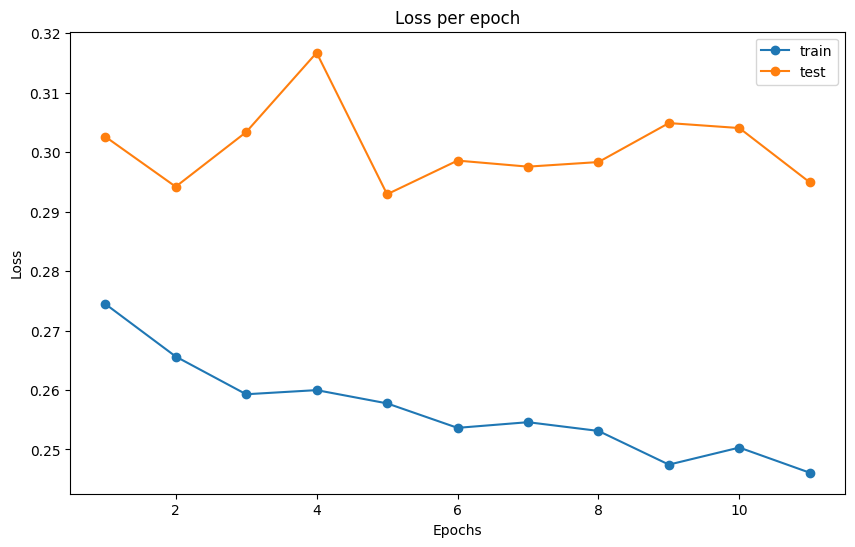

Train: 0.2476620123353295 Test: 0.3114526739478344
Train: 0.24617619029325497 Test: 0.30141995420232853
Train: 0.24450489316079158 Test: 0.30005722020917935
Train: 0.24087579770861478 Test: 0.30010954986306426
Train: 0.23847990357241633 Test: 0.2942335359301948
Train: 0.2351708432888807 Test: 0.33082449595946783
Train: 0.23443281737859192 Test: 0.31639155786172224
Train: 0.23737730116869912 Test: 0.2996404849530196
Train: 0.2334922464371524 Test: 0.2975572085055227
Train: 0.2283196570411558 Test: 0.3310060711399621


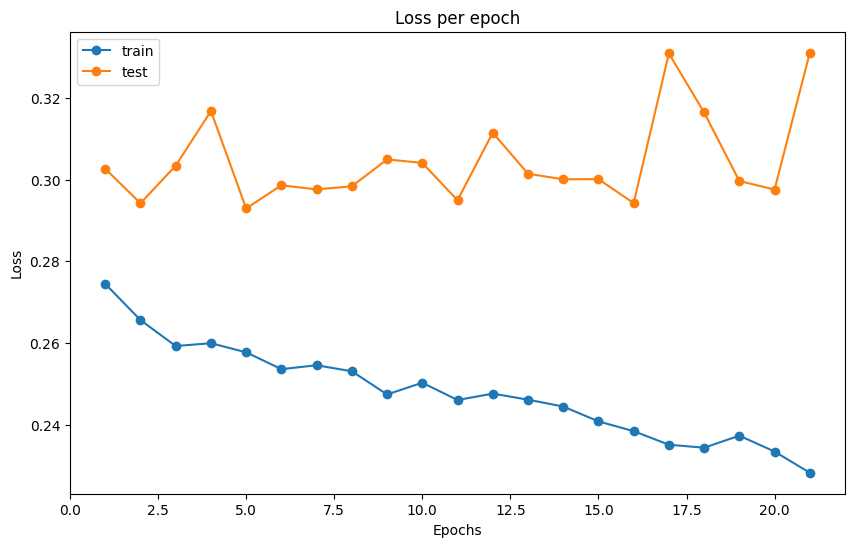

Train: 0.2270797470546694 Test: 0.30988027094400417
Train: 0.2262721012150895 Test: 0.3213564698923866
Train: 0.22903925573357087 Test: 0.3224083543927581
Train: 0.21869682349251218 Test: 0.324472617655702
Train: 0.22093386125117273 Test: 0.3205098190270437
Train: 0.21867809222737794 Test: 0.32789817774853514
Train: 0.21170366097617904 Test: 0.32983365922178676
Train: 0.21044133105718577 Test: 0.36896832940871255
Train: 0.21021249744417858 Test: 0.36379793332798904
Train: 0.20791472793314764 Test: 0.36568949073843554


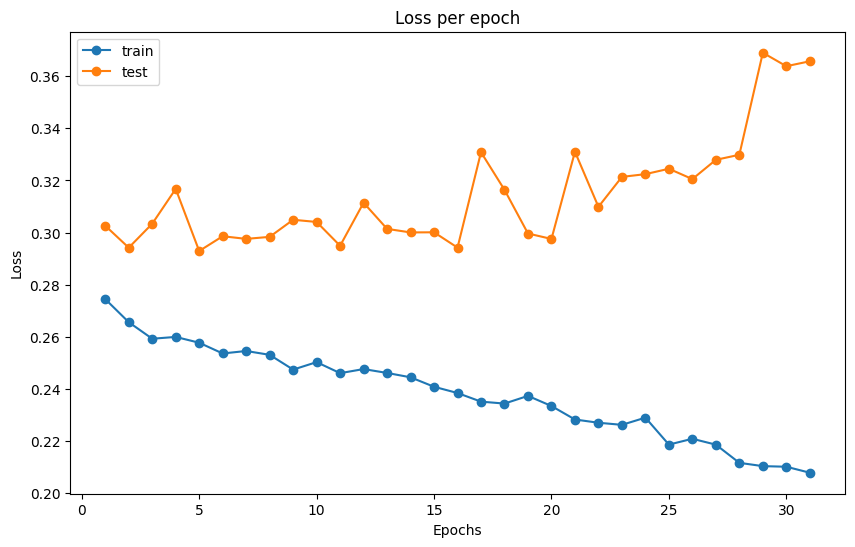

Train: 0.2092319673673563 Test: 0.3324387005546637
Train: 0.20425192657901217 Test: 0.3526145934361463
Train: 0.20342876202448631 Test: 0.3643286567450034


KeyboardInterrupt: 

In [45]:
pos_weight = torch.tensor([(3891 - 3104) / 3104]) # задаем штраф для оптимизатора из-за наличия дисбаланса классов
model = SiameseGNN()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
test_losses = {}
train_losses = {}

for epoch in range(100):
    train_loss = train_model(train_loader)
    train_losses[epoch+1] = train_loss
    
    test_loss = test_model(test_loader)
    test_losses[epoch+1] = test_loss
    print('Train:', train_loss, 'Test:', test_loss)
    if epoch > 1 and epoch % 10 == 0:
        plot_loss(train_losses, test_losses)


### Предсказываем результат

In [47]:
with torch.no_grad():
    model.eval()
    y_pred = []
    y_true = []
    for batch_wt, batch_mut, labels in test_loader:
        outputs = model(batch_wt, batch_mut)
        y_pred.append((torch.sigmoid(outputs)>0.5).long())
        y_true.append(labels)

In [50]:
y_pred = torch.cat(y_pred).numpy()
y_true = torch.cat(y_true).numpy()

In [51]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

         0.0       0.31      0.51      0.39       249
         1.0       0.80      0.64      0.71       777

    accuracy                           0.61      1026
   macro avg       0.56      0.58      0.55      1026
weighted avg       0.68      0.61      0.63      1026



### Мысли и рассуждения о том, как можно улучшить результат
Во-первых, сделать pdb файлы мутантных белков с релаксированной структурой, чтобы координаты атомов, водородные связя, доступная площадь поверхности растворителю поменялись. Во-вторых, как я уже писал можно добавить новые node_features с помощью Pymol\FoldX, добавить эмбединги из больших языковых моделей, например, ESM, или различные эволюционные характеристики последовательности: характеристики из Blossum, скоры из hhmer. Добавить edge_features:водородные связи, вандервальсовы взаимодейсвия и др. В-треьих, изменить архитектуру модели: поменять сверточные слои: на GAT, где реализован механизм внимания, реализовать иерархический пулинг для разных слоев сверток, поиграть с гиперпараметрами.
По-